# Allen-Cahn Latent KSWGD: Baseline Comparison

## Comparison Setup

This notebook compares particle-based latent-space generators for a single target distribution of stochastic Allen-Cahn fields.

1. Generate a late-time Allen-Cahn snapshot trajectory using the same PDE settings as `test_4_allen_cahn_1_stochastic.ipynb`.
2. Train an autoencoder and encode fields into standardized latent variables.
3. Train SDMD/Koopman spectrum on consecutive latent target pairs `(Z_tar, Z_tar_next)`.
4. Run KSWGD, using the learned SDMD/Koopman spectrum, from encoded initial-condition particles toward the fixed target distribution.
5. Run matched particle-based baselines from the same initial latent particles: ULA, SVGD, and Matrix SVGD.
6. Decode generated latent particles back to Allen-Cahn fields and compare field-level metrics.


In [129]:
# ============================================================
# Setup
# ============================================================

import os
import time
import random
import warnings
from pathlib import Path

import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    import sys
    import types
    import importlib.machinery
    plt = None
    matplotlib_stub = types.ModuleType('matplotlib')
    pyplot_stub = types.ModuleType('matplotlib.pyplot')
    matplotlib_stub.__spec__ = importlib.machinery.ModuleSpec('matplotlib', loader=None)
    pyplot_stub.__spec__ = importlib.machinery.ModuleSpec('matplotlib.pyplot', loader=None)
    matplotlib_stub.pyplot = pyplot_stub
    sys.modules['matplotlib'] = matplotlib_stub
    sys.modules['matplotlib.pyplot'] = pyplot_stub
    print('Warning: matplotlib is not installed; plotting cells will be skipped.')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# `solver_sdmd_torch_gpu` imports sklearn.model_selection.train_test_split.
# Keep a tiny fallback so this notebook can still run in lean environments.
try:
    import sklearn.model_selection  # noqa: F401
except ImportError:
    import sys
    import types
    import importlib.machinery

    sklearn_stub = types.ModuleType('sklearn')
    model_selection_stub = types.ModuleType('sklearn.model_selection')
    sklearn_stub.__spec__ = importlib.machinery.ModuleSpec('sklearn', loader=None)
    model_selection_stub.__spec__ = importlib.machinery.ModuleSpec('sklearn.model_selection', loader=None)

    def train_test_split(*arrays, test_size=0.25, random_state=None, shuffle=True):
        if not arrays:
            raise ValueError('At least one array is required.')
        n = len(arrays[0])
        rng = np.random.default_rng(random_state)
        indices = np.arange(n)
        if shuffle:
            rng.shuffle(indices)
        n_test = int(np.ceil(n * test_size)) if isinstance(test_size, float) else int(test_size)
        test_idx = indices[:n_test]
        train_idx = indices[n_test:]
        result = []
        for arr in arrays:
            result.extend([arr[train_idx], arr[test_idx]])
        return result

    model_selection_stub.train_test_split = train_test_split
    sklearn_stub.model_selection = model_selection_stub
    sys.modules['sklearn'] = sklearn_stub
    sys.modules['sklearn.model_selection'] = model_selection_stub

torch.set_default_dtype(torch.float64)

try:
    from tqdm.auto import tqdm, trange
except ImportError:
    import sys
    import types
    import importlib.machinery

    class _SimpleTqdm:
        def __init__(self, iterable=None, **kwargs):
            self.iterable = iterable if iterable is not None else []
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, *args, **kwargs):
            pass
        def close(self):
            pass

    def tqdm(iterable=None, **kwargs):
        return _SimpleTqdm(iterable, **kwargs)

    def trange(*args, **kwargs):
        return _SimpleTqdm(range(*args), **kwargs)

    tqdm_stub = types.ModuleType('tqdm')
    tqdm_auto_stub = types.ModuleType('tqdm.auto')
    tqdm_stub.__spec__ = importlib.machinery.ModuleSpec('tqdm', loader=None)
    tqdm_auto_stub.__spec__ = importlib.machinery.ModuleSpec('tqdm.auto', loader=None)
    tqdm_stub.tqdm = tqdm
    tqdm_auto_stub.tqdm = tqdm
    tqdm_auto_stub.trange = trange
    sys.modules['tqdm'] = tqdm_stub
    sys.modules['tqdm.auto'] = tqdm_auto_stub

# Fallbacks for optional imports used by solver_sdmd_torch_gpu.
try:
    import joblib  # noqa: F401
except ImportError:
    import pickle
    import sys
    import types
    import importlib.machinery
    joblib_stub = types.ModuleType('joblib')
    joblib_stub.__spec__ = importlib.machinery.ModuleSpec('joblib', loader=None)
    def dump(obj, filename):
        with open(filename, 'wb') as f:
            pickle.dump(obj, f)
    joblib_stub.dump = dump
    sys.modules['joblib'] = joblib_stub

try:
    import functorch  # noqa: F401
except ImportError:
    import sys
    import types
    import importlib.machinery
    import torch.func as torch_func
    functorch_stub = types.ModuleType('functorch')
    functorch_stub.__spec__ = importlib.machinery.ModuleSpec('functorch', loader=None)
    functorch_stub.vmap = torch_func.vmap
    functorch_stub.jacrev = torch_func.jacrev
    sys.modules['functorch'] = functorch_stub

import solver_sdmd_torch_gpu
from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch

RANDOM_SEED = 5
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device_compute = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = str(device_compute)
solver_sdmd_torch_gpu.device = device

FIG_DIR = Path('figures/allen_cahn')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def gaussian_filter1d(values, sigma=2.0):
    """Small numpy-only Gaussian smoother used for histogram display."""
    values = np.asarray(values, dtype=float)
    if sigma <= 0:
        return values
    radius = max(1, int(4 * sigma + 0.5))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma) ** 2)
    kernel /= kernel.sum()
    padded = np.pad(values, radius, mode='edge')
    return np.convolve(padded, kernel, mode='valid')


print('=' * 70)
print('Allen-Cahn latent KSWGD setup')
print('=' * 70)
print(f'Device: {device_compute}')
print(f'Random seed: {RANDOM_SEED}')
print('=' * 70)


Allen-Cahn latent KSWGD setup
Device: cuda
Random seed: 5


In [130]:
# ============================================================
# Stochastic Allen-Cahn PDE and trajectory generation
# ============================================================

class StochasticAllenCahn2D:
    """2D stochastic Allen-Cahn equation with additive noise."""

    def __init__(self, N=128, L=1.0, D=0.001, epsilon=0.01, sigma=1.4142, dt=2e-5):
        self.N = N
        self.L = L
        self.D = D
        self.epsilon = epsilon
        self.sigma = sigma
        self.dt = dt
        self.dx = L / N
        self.noise_scale = sigma * np.sqrt(dt)
        self.u = np.random.uniform(-0.5, 0.5, (N, N))

    def laplacian(self, u):
        u_top = np.roll(u, 1, axis=0)
        u_bottom = np.roll(u, -1, axis=0)
        u_left = np.roll(u, 1, axis=1)
        u_right = np.roll(u, -1, axis=1)
        return (u_top + u_bottom + u_left + u_right - 4.0 * u) / (self.dx ** 2)

    def step(self):
        reaction = -(1.0 / self.epsilon ** 2) * self.u * (self.u ** 2 - 1.0)
        diffusion = self.D * self.laplacian(self.u)
        dW = self.noise_scale * np.random.randn(self.N, self.N)
        self.u += self.dt * (diffusion + reaction) + dW
        self.u = np.clip(self.u, -1.5, 1.5)


def generate_ac_late_trajectory(
    n_snapshots=900,
    burnin_steps=25,
    save_every=1,
    N=128,
    dt=2e-5,
    epsilon=0.01,
    sigma=1.4142,
    D=0.001,
    verbose=True,
):
    """Generate one consecutive late-time PDE snapshot trajectory.

    After a burn-in, consecutive samples are treated as draws from one target
    distribution, and adjacent samples form `(X_tar, X_tar_next)` training pairs.
    """
    ac = StochasticAllenCahn2D(N=N, D=D, epsilon=epsilon, sigma=sigma, dt=dt)
    total_steps = burnin_steps + (n_snapshots - 1) * save_every
    snapshots = []
    snapshot_steps = []
    transition_probe = {0, 1, 2, 5, 10, burnin_steps}
    transition = {}

    iterator = range(total_steps + 1)
    if tqdm is not None and verbose:
        iterator = tqdm(iterator, desc='AC trajectory', unit='step')

    for step in iterator:
        if step in transition_probe:
            transition[step] = ac.u.copy()
        if step >= burnin_steps and (step - burnin_steps) % save_every == 0:
            snapshots.append(ac.u.copy())
            snapshot_steps.append(step)
            if len(snapshots) >= n_snapshots:
                break
        ac.step()

    snapshots = np.asarray(snapshots, dtype=np.float32)
    snapshot_times = np.asarray(snapshot_steps, dtype=np.float64) * dt

    if verbose:
        print('=' * 70)
        print('Allen-Cahn latent target trajectory')
        print('=' * 70)
        print(f'snapshots shape: {snapshots.shape}')
        print(f'burnin steps: {burnin_steps}  save_every: {save_every}')
        print(f'time window: [{snapshot_times[0]:.6g}, {snapshot_times[-1]:.6g}]')
        print(f'pair dt: {save_every * dt:.6g}')
        print(f'u stats: mean={snapshots.mean():.4f}, std={snapshots.std():.4f}, min={snapshots.min():.4f}, max={snapshots.max():.4f}')
        print(f'fraction |u| > 0.8: {np.mean(np.abs(snapshots) > 0.8):.2%}')
        print('=' * 70)

    return snapshots, snapshot_times, transition



def sample_ac_initial_fields(
    n_samples,
    N=128,
    mode='uniform_fields',
    low=-0.5,
    high=0.5,
    noise_std=0.15,
    seed=None,
):
    """Create off-target initial fields for KSWGD particles.

    These fields define iteration 0. They are encoded by the AE into latent
    particles, so the decoded iter-0 histogram should look like the chosen
    initial field law rather than the target two-peak law.
    """
    rng = np.random.default_rng(seed)
    if mode == 'uniform_fields':
        fields = rng.uniform(low, high, size=(n_samples, N, N))
    elif mode == 'zero_gaussian_fields':
        fields = rng.normal(0.0, noise_std, size=(n_samples, N, N))
    elif mode == 'constant_zero_fields':
        fields = np.zeros((n_samples, N, N), dtype=np.float64)
    else:
        raise ValueError(f'Unknown initial field mode: {mode}')
    return fields.astype(np.float32)


In [131]:
# ============================================================
# Autoencoder for high-dimensional Allen-Cahn fields
# ============================================================

class ACEncoder(nn.Module):
    def __init__(self, input_size=128, latent_dim=16):
        super().__init__()
        flat_size = input_size * input_size
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class ACDecoder(nn.Module):
    def __init__(self, input_size=128, latent_dim=16):
        super().__init__()
        flat_size = input_size * input_size
        self.input_size = input_size
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, flat_size),
            nn.Tanh(),
        )

    def forward(self, z):
        x_flat = self.net(z)
        return x_flat.view(-1, self.input_size, self.input_size)


class ACAutoencoder(nn.Module):
    def __init__(self, input_size=128, latent_dim=16):
        super().__init__()
        self.encoder = ACEncoder(input_size=input_size, latent_dim=latent_dim)
        self.decoder = ACDecoder(input_size=input_size, latent_dim=latent_dim)
        self.latent_dim = latent_dim

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


def train_autoencoder(fields, latent_dim=16, n_epochs=120, batch_size=32, lr=1e-3, verbose=True):
    n_samples, N, _ = fields.shape
    data_flat = fields.reshape(n_samples, N * N)
    data_min = float(data_flat.min())
    data_max = float(data_flat.max())
    data_range = data_max - data_min + 1e-8
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0

    train_tensor = torch.as_tensor(data_scaled, dtype=torch.float64, device=device_compute)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    ae = ACAutoencoder(input_size=N, latent_dim=latent_dim).to(device_compute).double()
    optimizer = optim.Adam(ae.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    iterator = range(n_epochs)
    if tqdm is not None and verbose:
        iterator = trange(n_epochs, desc='AE training', unit='epoch')

    for epoch in iterator:
        total_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.view(-1, N, N)
            optimizer.zero_grad()
            recon, _ = ae(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.shape[0]
        epoch_loss = total_loss / n_samples
        if verbose and tqdm is not None:
            iterator.set_postfix(loss=f'{epoch_loss:.4e}', refresh=False)
        elif verbose and (epoch + 1) % 25 == 0:
            print(f'AE epoch {epoch + 1}/{n_epochs}: loss={epoch_loss:.6e}')

    return ae, data_min, data_max


def encode_fields(ae, fields, data_min, data_max):
    n_samples, N, _ = fields.shape
    data_range = data_max - data_min + 1e-8
    data_flat = fields.reshape(n_samples, N * N)
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
    with torch.no_grad():
        tensor = torch.as_tensor(data_scaled, dtype=torch.float64, device=device_compute).view(-1, N, N)
        z = ae.encoder(tensor).detach().cpu().numpy()
    return z.astype(np.float64)


def decode_latent(ae, z, N, data_min, data_max, batch_size=256):
    data_range = data_max - data_min + 1e-8
    decoded_batches = []
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            z_tensor = torch.as_tensor(z[start:start + batch_size], dtype=torch.float64, device=device_compute)
            decoded = ae.decoder(z_tensor).detach().cpu().numpy()
            decoded_batches.append(decoded)
    decoded = np.concatenate(decoded_batches, axis=0)
    fields = (decoded.reshape(-1, N * N) + 1.0) / 2.0 * data_range + data_min
    return fields.reshape(-1, N, N)


In [132]:
# ============================================================
# Target kernel and generic latent KSWGD runner
# ============================================================

def build_target_kernel_torch(
    X_train,
    c_epsilon=0.5,
    X_reference=None,
    reference_scale=0.5,
    epsilon_override=None,
):
    """Build normalized target-kernel objects used by the KSWGD update.

    For AC latent sampling the initial particles can be far from the late-time
    target cluster. If epsilon is estimated only from target-target distances,
    K(init, target) can underflow to zero and the particles will not move. When
    X_reference is provided, the bandwidth is widened so the initial particles
    still have nonzero kernel overlap with the target cloud.
    """
    X_train_gpu = torch.as_tensor(X_train, dtype=torch.float64, device=device_compute)
    n = X_train.shape[0]

    sq_train_gpu = torch.sum(X_train_gpu ** 2, dim=1)
    H_gpu = sq_train_gpu[:, None] + sq_train_gpu[None, :] - 2.0 * (X_train_gpu @ X_train_gpu.T)
    epsilon_target = float((torch.median(H_gpu) * (c_epsilon / np.log(n + 1))).detach().cpu().item())
    epsilon_target = max(epsilon_target, 1e-10)

    epsilon_reference = None
    if X_reference is not None:
        X_ref_gpu = torch.as_tensor(X_reference, dtype=torch.float64, device=device_compute)
        sq_ref_gpu = torch.sum(X_ref_gpu ** 2, dim=1)
        H_ref_gpu = sq_ref_gpu[:, None] + sq_train_gpu[None, :] - 2.0 * (X_ref_gpu @ X_train_gpu.T)
        epsilon_reference = float((reference_scale * torch.median(H_ref_gpu)).detach().cpu().item())
        epsilon_reference = max(epsilon_reference, 1e-10)

    if epsilon_override is not None:
        epsilon = float(epsilon_override)
    elif epsilon_reference is not None:
        epsilon = max(epsilon_target, epsilon_reference)
    else:
        epsilon = epsilon_target
    epsilon = max(epsilon, 1e-10)

    data_kernel_gpu = torch.exp(-H_gpu / (2.0 * epsilon))
    p_x_gpu = torch.sqrt(torch.sum(data_kernel_gpu, dim=1) + 1e-14)
    data_kernel_norm_gpu = data_kernel_gpu / p_x_gpu[:, None] / p_x_gpu[None, :]
    D_y_gpu = torch.sum(data_kernel_norm_gpu, dim=0) + 1e-14

    return {
        'X_train_gpu': X_train_gpu,
        'p_x_gpu': p_x_gpu,
        'D_y_gpu': D_y_gpu,
        'epsilon': epsilon,
        'epsilon_target': epsilon_target,
        'epsilon_reference': epsilon_reference,
        'epsilon_override': epsilon_override,
        'n_train': n,
    }


def evaluate_kernel_at_points(X_query, X_data, epsilon_val, p_x_val, D_y_val):
    if not isinstance(X_query, torch.Tensor):
        X_query = torch.as_tensor(X_query, dtype=torch.float64, device=device_compute)
    sq_query = torch.sum(X_query ** 2, dim=1)
    sq_data = torch.sum(X_data ** 2, dim=1)
    H = sq_query[:, None] + sq_data[None, :] - 2.0 * (X_query @ X_data.T)
    K_raw = torch.exp(-H / (2.0 * epsilon_val))
    p_query = torch.sqrt(torch.sum(K_raw, dim=1, keepdim=True) + 1e-14)
    K_norm = K_raw / p_query / p_x_val[None, :]
    return K_norm / D_y_val[None, :]


def compute_kernel_gradient(X_query, X_data, epsilon_val, p_x_val):
    if not isinstance(X_query, torch.Tensor):
        X_query = torch.as_tensor(X_query, dtype=torch.float64, device=device_compute)
    diff = X_query[:, None, :] - X_data[None, :, :]
    sq_query = torch.sum(X_query ** 2, dim=1)
    sq_data = torch.sum(X_data ** 2, dim=1)
    H = sq_query[:, None] + sq_data[None, :] - 2.0 * (X_query @ X_data.T)
    K_raw = torch.exp(-H / (2.0 * epsilon_val))
    grad_K_raw = -K_raw[:, :, None] * diff / epsilon_val
    p_query = torch.sqrt(torch.sum(K_raw, dim=1, keepdim=True) + 1e-14)
    return grad_K_raw / p_query[:, :, None] / p_x_val[None, :, None]


def target_nn_distance(Z_particles, Z_target, max_target=2000):
    if Z_target.shape[0] > max_target:
        idx = np.random.choice(Z_target.shape[0], size=max_target, replace=False)
        Z_ref = Z_target[idx]
    else:
        Z_ref = Z_target
    diff = Z_particles[:, None, :] - Z_ref[None, :, :]
    distances = np.sqrt(np.sum(diff * diff, axis=2))
    return float(np.mean(np.min(distances, axis=1)))


def run_latent_kswgd_with_spectrum(
    method_name,
    Z_init,
    Z_target,
    target_kernel,
    eigvecs_on_target,
    lambda_gen_full_values,
    eigvals_for_mode_selection=None,
    fixed_mode_count=60,
    eig_threshold_value=1e-3,
    n_skip_modes=1,
    n_iter=1500,
    step_size=0.02,
    record_every=100,
    adaptive_step=True,
    target_initial_movement=0.02,
    max_step_multiplier=1e13,
    max_particle_step=0.05,
):
    """Generic-dimensional latent KSWGD loop using a learned SDMD spectrum.

    AC latent coordinates can make the raw KSWGD force extremely small. The
    optional adaptive step keeps the KSWGD force direction but rescales the
    global learning rate so the first average latent move is visible. This is
    recorded in the metrics instead of being hidden.
    """
    if eigvals_for_mode_selection is None:
        eigvals_for_mode_selection = lambda_gen_full_values

    eigvals_after_skip = np.asarray(eigvals_for_mode_selection)[n_skip_modes:]
    if fixed_mode_count is not None:
        k_modes = min(int(fixed_mode_count), len(eigvals_after_skip))
    else:
        k_modes = int(np.sum(eigvals_after_skip.real > eig_threshold_value))
    if k_modes <= 0:
        raise RuntimeError('No Koopman/SDMD modes selected for KSWGD.')

    mode_start = n_skip_modes
    mode_end = mode_start + k_modes
    lambda_gen_selected = np.asarray(lambda_gen_full_values)[mode_start:mode_end]
    lambda_inv = np.zeros(k_modes, dtype=np.complex128)
    mask = np.abs(lambda_gen_selected) > 1e-8
    lambda_inv[mask] = 1.0 / lambda_gen_selected[mask]

    eigvecs_selected_gpu = torch.as_tensor(
        np.real(eigvecs_on_target[:, mode_start:mode_end]),
        dtype=torch.float64,
        device=device_compute,
    )
    lambda_inv_gpu = torch.as_tensor(lambda_inv, dtype=torch.complex128, device=device_compute)

    X_train_gpu = target_kernel['X_train_gpu']
    p_x_gpu = target_kernel['p_x_gpu']
    D_y_gpu = target_kernel['D_y_gpu']
    epsilon_val = target_kernel['epsilon']

    n_particles, latent_dim = Z_init.shape
    Z_traj = np.zeros((n_particles, latent_dim, n_iter + 1), dtype=np.float64)
    Z_traj[:, :, 0] = Z_init.copy()

    def compute_kswgd_force(Z_curr_np):
        Z_curr_gpu_local = torch.as_tensor(Z_curr_np, dtype=torch.float64, device=device_compute)
        K_curr_gpu_local = evaluate_kernel_at_points(Z_curr_gpu_local, X_train_gpu, epsilon_val, p_x_gpu, D_y_gpu)
        c_gpu = eigvecs_selected_gpu.T @ K_curr_gpu_local.T
        c_inv_gpu = lambda_inv_gpu[:, None] * c_gpu.to(torch.complex128)
        f_inv_gpu = eigvecs_selected_gpu @ c_inv_gpu.real
        grad_K_gpu = compute_kernel_gradient(Z_curr_gpu_local, X_train_gpu, epsilon_val, p_x_gpu)
        grad_drive_gpu_local = torch.sum(grad_K_gpu * f_inv_gpu.T[:, :, None], dim=1)
        return grad_drive_gpu_local, K_curr_gpu_local

    with torch.no_grad():
        initial_force_gpu, K0_gpu = compute_kswgd_force(Z_init)
        initial_kernel_mean = float(K0_gpu.mean().detach().cpu().item())
        initial_kernel_max = float(K0_gpu.max().detach().cpu().item())
        initial_force_norm = float(torch.mean(torch.linalg.norm(initial_force_gpu, dim=1)).detach().cpu().item())

    effective_step_size = float(step_size)
    step_multiplier = 1.0
    if adaptive_step:
        raw_initial_movement = max(step_size * initial_force_norm, 1e-300)
        step_multiplier = min(max_step_multiplier, target_initial_movement / raw_initial_movement)
        effective_step_size = float(step_size * step_multiplier)

    metrics = {
        'steps': [0],
        'target_nn_distance': [target_nn_distance(Z_init, Z_target)],
        'mean_norm': [float(np.mean(np.linalg.norm(Z_init, axis=1)))],
        'movement_rate': [0.0],
        'kernel_mean': [initial_kernel_mean],
        'kernel_max': [initial_kernel_max],
        'force_norm': [initial_force_norm],
        'effective_step_size': [effective_step_size],
    }

    print('=' * 70)
    print(f'{method_name}: latent KSWGD')
    print('=' * 70)
    print(f'target samples: {Z_target.shape[0]}')
    print(f'particles: {n_particles}')
    print(f'latent dim: {latent_dim}')
    print(f'kernel epsilon: {epsilon_val:.6e}')
    print(f'initial mean/max K(init,target): {initial_kernel_mean:.3e} / {initial_kernel_max:.3e}')
    print(f'initial force norm: {initial_force_norm:.3e}')
    print(f'base step size: {step_size:.3e}')
    print(f'adaptive step: {adaptive_step}')
    print(f'effective step size: {effective_step_size:.3e} (multiplier={step_multiplier:.3e})')
    print(f'max particle step: {max_particle_step}')
    print(f'modes: {k_modes} (skip first {n_skip_modes})')
    print(f'iterations: {n_iter}, record_every: {record_every}')
    print(f'initial target-NN distance: {metrics["target_nn_distance"][-1]:.6f}')
    print('=' * 70)

    iterator = range(n_iter)
    if tqdm is not None:
        iterator = trange(n_iter, desc=method_name, unit='iter')

    for it in iterator:
        Z_curr = Z_traj[:, :, it]
        grad_drive_gpu, _ = compute_kswgd_force(Z_curr)
        raw_update_gpu = -effective_step_size * grad_drive_gpu

        if max_particle_step is not None and max_particle_step > 0:
            update_norm_gpu = torch.linalg.norm(raw_update_gpu, dim=1, keepdim=True)
            clip_factor_gpu = torch.clamp(max_particle_step / (update_norm_gpu + 1e-300), max=1.0)
            raw_update_gpu = raw_update_gpu * clip_factor_gpu

        Z_curr_gpu = torch.as_tensor(Z_curr, dtype=torch.float64, device=device_compute)
        Z_next_gpu = Z_curr_gpu + raw_update_gpu
        Z_next = Z_next_gpu.detach().cpu().numpy()
        Z_traj[:, :, it + 1] = Z_next

        if (it + 1) % record_every == 0 or (it + 1) == n_iter:
            movement = float(np.mean(np.linalg.norm(Z_next - Z_curr, axis=1)))
            nn_dist = target_nn_distance(Z_next, Z_target)
            with torch.no_grad():
                force_next_gpu, K_next_gpu = compute_kswgd_force(Z_next)
            metrics['steps'].append(it + 1)
            metrics['target_nn_distance'].append(nn_dist)
            metrics['mean_norm'].append(float(np.mean(np.linalg.norm(Z_next, axis=1))))
            metrics['movement_rate'].append(movement)
            metrics['kernel_mean'].append(float(K_next_gpu.mean().detach().cpu().item()))
            metrics['kernel_max'].append(float(K_next_gpu.max().detach().cpu().item()))
            metrics['force_norm'].append(float(torch.mean(torch.linalg.norm(force_next_gpu, dim=1)).detach().cpu().item()))
            metrics['effective_step_size'].append(effective_step_size)
            if hasattr(iterator, 'set_postfix'):
                iterator.set_postfix(nn=f'{nn_dist:.4f}', move=f'{movement:.2e}', force=f'{metrics["force_norm"][-1]:.1e}', refresh=False)

    for key in metrics:
        metrics[key] = np.asarray(metrics[key])

    print(f'{method_name} complete.')
    print(f'final target-NN distance: {metrics["target_nn_distance"][-1]:.6f}')
    return Z_traj, metrics, k_modes


In [133]:
# ============================================================
# Main experiment parameters
# ============================================================

# PDE / data
N = 128
DT_SIM = 2e-5
EPSILON_PDE = 0.01
SIGMA_NOISE = 1.4142
N_SNAPSHOTS = 900
BURNIN_STEPS = 25
SAVE_EVERY = 1

# AE
LATENT_DIM = 16
AE_EPOCHS = 120
AE_BATCH_SIZE = 32

# SDMD / Koopman generator spectrum
SDMD_EPOCHS = 6
SDMD_BATCH_SIZE = 256
SDMD_LR = 1e-5
N_PSI_TRAIN = 64
SDMD_LAYER_SIZES = [64, 64]
SDMD_REG = 0.1
TRAIN_FRACTION = 0.7

# KSWGD
KSWGD_LABEL = 'KSWGD'
N_INIT_PARTICLES = 300
N_ITER_KSWGD = 500
COMPARISON_SNAPSHOT_STEPS = [0, 10, 20, 30, 40, 50, 100, 500]
H_KSWGD = 0.08
RECORD_INTERVAL = 100
N_SKIP = 1
K_MODES_SDMD_FIXED = 60
EIG_THRESHOLD = 1e-3
C_EPSILON = 0.5
KERNEL_REFERENCE_MODE = 'init_target'
KERNEL_INIT_TARGET_SCALE = 0.2
KERNEL_EPSILON_OVERRIDE = None
NORMALIZE_LATENT_FOR_KSWGD = True
KSWGD_ADAPTIVE_STEP = True
KSWGD_TARGET_INITIAL_MOVEMENT = 0.02
KSWGD_MAX_STEP_MULTIPLIER = 1e13
KSWGD_MAX_PARTICLE_STEP = 0.05

# Iteration-0 particle law. This is intentionally off-target.
# Use 'uniform_fields' for Allen-Cahn random initial conditions,
# 'zero_gaussian_fields' for a single central pixel-value peak, or
# 'target_scaled_gaussian_latent' to reproduce the old near-target latent Gaussian.
INIT_MODE = 'uniform_fields'
INIT_FIELD_LOW = -0.5
INIT_FIELD_HIGH = 0.5
INIT_FIELD_NOISE_STD = 0.15
INIT_POOL_SIZE = max(N_INIT_PARTICLES, 300)
INIT_LATENT_JITTER = 0.0
INIT_STD_SCALE = 1.5

print('=' * 70)
print('Experiment parameters')
print('=' * 70)
for name in [
    'N', 'DT_SIM', 'EPSILON_PDE', 'SIGMA_NOISE', 'N_SNAPSHOTS', 'BURNIN_STEPS',
    'SAVE_EVERY', 'LATENT_DIM', 'AE_EPOCHS', 'SDMD_EPOCHS', 'N_INIT_PARTICLES',
    'N_ITER_KSWGD', 'COMPARISON_SNAPSHOT_STEPS', 'H_KSWGD', 'K_MODES_SDMD_FIXED',
    'INIT_MODE', 'NORMALIZE_LATENT_FOR_KSWGD', 'KERNEL_REFERENCE_MODE',
    'KSWGD_ADAPTIVE_STEP', 'KSWGD_TARGET_INITIAL_MOVEMENT', 'KSWGD_MAX_PARTICLE_STEP'
]:
    print(f'{name:28s} = {globals()[name]}')
print('=' * 70)


Experiment parameters
N                            = 128
DT_SIM                       = 2e-05
EPSILON_PDE                  = 0.01
SIGMA_NOISE                  = 1.4142
N_SNAPSHOTS                  = 900
BURNIN_STEPS                 = 25
SAVE_EVERY                   = 1
LATENT_DIM                   = 16
AE_EPOCHS                    = 120
SDMD_EPOCHS                  = 6
N_INIT_PARTICLES             = 300
N_ITER_KSWGD                 = 500
COMPARISON_SNAPSHOT_STEPS    = [0, 10, 20, 30, 40, 50, 100, 500]
H_KSWGD                      = 0.08
K_MODES_SDMD_FIXED           = 60
INIT_MODE                    = uniform_fields
NORMALIZE_LATENT_FOR_KSWGD   = True
KERNEL_REFERENCE_MODE        = init_target
KSWGD_ADAPTIVE_STEP          = True
KSWGD_TARGET_INITIAL_MOVEMENT = 0.02
KSWGD_MAX_PARTICLE_STEP      = 0.05


In [134]:
# ============================================================
# Step 1: Generate one late-time target trajectory from the PDE
# ============================================================

fields, snapshot_times, transition_fields = generate_ac_late_trajectory(
    n_snapshots=N_SNAPSHOTS,
    burnin_steps=BURNIN_STEPS,
    save_every=SAVE_EVERY,
    N=N,
    dt=DT_SIM,
    epsilon=EPSILON_PDE,
    sigma=SIGMA_NOISE,
    verbose=True,
)

# Consecutive late-time fields form target training pairs.
# These high-dimensional pairs become Z_tar and Z_tar_next after AE encoding.
fields_tar = fields[:-1]
fields_tar_next = fields[1:]
PAIR_DT = SAVE_EVERY * DT_SIM

init_field_pool = None
if INIT_MODE in {'uniform_fields', 'zero_gaussian_fields', 'constant_zero_fields'}:
    init_field_pool = sample_ac_initial_fields(
        INIT_POOL_SIZE,
        N=N,
        mode=INIT_MODE,
        low=INIT_FIELD_LOW,
        high=INIT_FIELD_HIGH,
        noise_std=INIT_FIELD_NOISE_STD,
        seed=RANDOM_SEED + 101,
    )
    print(f'init_field_pool shape: {init_field_pool.shape}  mode={INIT_MODE}')
    print(f'init field stats: mean={init_field_pool.mean():+.4f}, std={init_field_pool.std():.4f}, '
          f'|u|>0.8={np.mean(np.abs(init_field_pool) > 0.8):.2%}')

print(f'fields_tar shape:      {fields_tar.shape}')
print(f'fields_tar_next shape: {fields_tar_next.shape}')
print(f'PAIR_DT = {PAIR_DT:.6g}')


AC trajectory: 100%|█████████▉| 924/925 [00:00<00:00, 2218.11step/s]


Allen-Cahn latent target trajectory
snapshots shape: (900, 128, 128)
burnin steps: 25  save_every: 1
time window: [0.0005, 0.01848]
pair dt: 2e-05
u stats: mean=0.0088, std=0.9966, min=-1.0381, max=1.0428
fraction |u| > 0.8: 99.98%
init_field_pool shape: (300, 128, 128)  mode=uniform_fields
init field stats: mean=+0.0001, std=0.2888, |u|>0.8=0.00%
fields_tar shape:      (899, 128, 128)
fields_tar_next shape: (899, 128, 128)
PAIR_DT = 2e-05


In [135]:
# ============================================================
# Step 2: Train AE and encode the PDE trajectory into latent space
# ============================================================

ae_training_fields = fields
if init_field_pool is not None:
    # The target distribution remains the late-time trajectory fields.
    # The initial pool is included only so the AE latent chart can decode iter-0 particles sensibly.
    ae_training_fields = np.concatenate([fields, init_field_pool], axis=0)
    print(f'AE training fields include target + initial pool: {ae_training_fields.shape}')
else:
    print(f'AE training fields: {ae_training_fields.shape}')

ae, data_min, data_max = train_autoencoder(
    ae_training_fields,
    latent_dim=LATENT_DIM,
    n_epochs=AE_EPOCHS,
    batch_size=AE_BATCH_SIZE,
    lr=1e-3,
    verbose=True,
)
ae.eval()

Z_all_raw = encode_fields(ae, fields, data_min, data_max)
Z_tar_raw = Z_all_raw[:-1].copy()
Z_tar_next_raw = Z_all_raw[1:].copy()
Z_init_pool_raw = encode_fields(ae, init_field_pool, data_min, data_max) if init_field_pool is not None else None

if NORMALIZE_LATENT_FOR_KSWGD:
    latent_refs = [Z_tar_raw, Z_tar_next_raw]
    if Z_init_pool_raw is not None:
        latent_refs.append(Z_init_pool_raw)
    latent_norm_ref = np.concatenate(latent_refs, axis=0)
    latent_shift = latent_norm_ref.mean(axis=0)
    latent_scale = latent_norm_ref.std(axis=0) + 1e-8
else:
    latent_shift = np.zeros(LATENT_DIM, dtype=np.float64)
    latent_scale = np.ones(LATENT_DIM, dtype=np.float64)


def to_kswgd_latent(z_raw):
    return (z_raw - latent_shift) / latent_scale


def from_kswgd_latent(z_scaled):
    return z_scaled * latent_scale + latent_shift


def decode_kswgd_latent(z_scaled):
    return decode_latent(ae, from_kswgd_latent(z_scaled), N, data_min, data_max)

Z_all = to_kswgd_latent(Z_all_raw)
Z_tar = to_kswgd_latent(Z_tar_raw)
Z_tar_next = to_kswgd_latent(Z_tar_next_raw)
Z_init_pool = to_kswgd_latent(Z_init_pool_raw) if Z_init_pool_raw is not None else None

print('=' * 70)
print('Latent data')
print('=' * 70)
print(f'Z_all raw shape:      {Z_all_raw.shape}')
print(f'Z_tar shape:          {Z_tar.shape}')
print(f'Z_tar_next shape:     {Z_tar_next.shape}')
print(f'latent normalized:    {NORMALIZE_LATENT_FOR_KSWGD}')
print(f'scaled target mean first 5 dims: {Z_tar.mean(axis=0)[:5]}')
print(f'scaled target std first 5 dims:  {Z_tar.std(axis=0)[:5]}')
if Z_init_pool is not None:
    print(f'Z_init_pool shape: {Z_init_pool.shape}')
    print(f'scaled init mean first 5 dims: {Z_init_pool.mean(axis=0)[:5]}')
    print(f'scaled init std first 5 dims:  {Z_init_pool.std(axis=0)[:5]}')
print('=' * 70)

# AE reconstruction diagnostic: this should already preserve the target two-peak pixel histogram.
recon_fields_tar = decode_kswgd_latent(Z_tar[:min(300, len(Z_tar))])
print('AE target reconstruction diagnostic:')
print(f'  target std={fields_tar[:len(recon_fields_tar)].std():.4f}, recon std={recon_fields_tar.std():.4f}')
print(f'  target |u|>0.8={np.mean(np.abs(fields_tar[:len(recon_fields_tar)]) > 0.8):.2%}, '
      f'recon |u|>0.8={np.mean(np.abs(recon_fields_tar) > 0.8):.2%}')
if Z_init_pool is not None:
    recon_init_fields = decode_kswgd_latent(Z_init_pool[:min(300, len(Z_init_pool))])
    init_ref = init_field_pool[:len(recon_init_fields)]
    print('AE initial-particle reconstruction diagnostic:')
    print(f'  init ref std={init_ref.std():.4f}, recon std={recon_init_fields.std():.4f}')
    print(f'  init ref |u|>0.8={np.mean(np.abs(init_ref) > 0.8):.2%}, '
          f'recon |u|>0.8={np.mean(np.abs(recon_init_fields) > 0.8):.2%}')


AE training fields include target + initial pool: (1200, 128, 128)


AE training: 100%|██████████| 120/120 [00:28<00:00,  4.22epoch/s, loss=1.2848e-02]


Latent data
Z_all raw shape:      (900, 16)
Z_tar shape:          (899, 16)
Z_tar_next shape:     (899, 16)
latent normalized:    True
scaled target mean first 5 dims: [ 0.40826618 -0.40826015 -0.3578148  -0.40800125  0.40814351]
scaled target std first 5 dims:  [0.0027008  0.00279161 0.00240244 0.00272003 0.00272644]
Z_init_pool shape: (300, 16)
scaled init mean first 5 dims: [-2.44702706  2.44699606  2.14463617  2.44544055 -2.44629349]
scaled init std first 5 dims:  [0.07908627 0.08018195 1.27530761 0.12373838 0.10218829]
AE target reconstruction diagnostic:
  target std=0.9964, recon std=1.0404
  target |u|>0.8=99.95%, recon |u|>0.8=100.00%
AE initial-particle reconstruction diagnostic:
  init ref std=0.2888, recon std=0.1892
  init ref |u|>0.8=0.00%, recon |u|>0.8=0.00%


In [136]:
# ============================================================
# Step 3: Kernel construction is delayed until Z_init is available
# ============================================================

# The target kernel bandwidth needs to know whether the initial particles are
# far from the target latent cloud. If it is built only from target-target
# distances, K(init, target) can become exactly zero and KSWGD will not move.
target_kernel = None
print('=' * 70)
print('Target kernel will be built after Z_init is constructed.')
print('This allows the bandwidth to include init-target overlap diagnostics.')
print('=' * 70)


Target kernel will be built after Z_init is constructed.
This allows the bandwidth to include init-target overlap diagnostics.


In [137]:
# ============================================================
# Step 4: Train SDMD / Koopman generator spectrum in latent space
# ============================================================

len_all = Z_tar.shape[0]
train_cut = int(TRAIN_FRACTION * len_all)

# Keep the ordering because the generator estimator in solver_sdmd_torch_gpu uses adjacent rows.
data_x_train = Z_tar[:train_cut]
data_y_train = Z_tar_next[:train_cut]
data_x_valid = Z_tar[train_cut + 1:]
data_y_valid = Z_tar_next[train_cut + 1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print('=' * 70)
print('SDMD training data')
print('=' * 70)
print(f'train X/Y: {data_x_train.shape} / {data_y_train.shape}')
print(f'valid X/Y: {data_x_valid.shape} / {data_y_valid.shape}')
print(f'pair dt: {PAIR_DT:.6g}')
print('=' * 70)

checkpoint_prefix = 'ac_latent_sdmd_kswgd'
basis_function = KoopmanNNTorch(
    input_size=LATENT_DIM,
    layer_sizes=SDMD_LAYER_SIZES,
    n_psi_train=N_PSI_TRAIN,
).to(device_compute).double()

solver = KoopmanSolverTorch(
    dic=basis_function,
    target_dim=LATENT_DIM,
    reg=SDMD_REG,
    checkpoint_file=f'{checkpoint_prefix}_koopman.torch',
    fnn_checkpoint_file=f'{checkpoint_prefix}_fnn.torch',
    a_b_file=f'{checkpoint_prefix}_ab.jbl',
    generator_batch_size=2,
    fnn_batch_size=64,
    delta_t=PAIR_DT,
)

solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=SDMD_EPOCHS,
    batch_size=SDMD_BATCH_SIZE,
    lr=SDMD_LR,
    log_interval=10,
    lr_decay_factor=0.8,
)

# Convert Koopman eigenvalues to generator eigenvalues.
evalues_sdmd = solver.eigenvalues.T
eigvals_K_sdmd = np.real(evalues_sdmd)
lambda_gen_full_sdmd = (eigvals_K_sdmd - 1.0) / PAIR_DT

# Important: KSWGD target kernel is on Z_tar, so evaluate learned eigenfunctions on Z_tar.
eigvecs_K_sdmd_on_target = np.real(solver.eigenfunctions(Z_tar))

print('=' * 70)
print('SDMD spectrum')
print('=' * 70)
print(f'eigvals_K_sdmd shape: {eigvals_K_sdmd.shape}')
print(f'eigfuncs on target shape: {eigvecs_K_sdmd_on_target.shape}')
print('top 10 real Koopman eigenvalues:')
print(np.real(eigvals_K_sdmd[:10]))
print('=' * 70)


SDMD training data
train X/Y: (629, 16) / (629, 16)
valid X/Y: (269, 16) / (269, 16)
pair dt: 2e-05
Epoch: 1 	Training Loss: 0.202106 	Validation Loss: 0.162316
Saving model, validation loss improved: 0.162316 < 10000.000000
Epoch: 2 	Training Loss: 0.137834 	Validation Loss: 0.107403
Saving model, validation loss improved: 0.107403 < 0.162316


Epoch: 3 	Training Loss: 0.089315 	Validation Loss: 0.066801
Saving model, validation loss improved: 0.066801 < 0.107403
Epoch: 4 	Training Loss: 0.054038 	Validation Loss: 0.037902
Saving model, validation loss improved: 0.037902 < 0.066801
Epoch: 5 	Training Loss: 0.029338 	Validation Loss: 0.019039
Saving model, validation loss improved: 0.019039 < 0.037902
Epoch: 6 	Training Loss: 0.014151 	Validation Loss: 0.008032
Saving model, validation loss improved: 0.008032 < 0.019039
Epoch: 7 	Training Loss: 0.005870 	Validation Loss: 0.002778
Saving model, validation loss improved: 0.002778 < 0.008032
Epoch: 8 	Training Loss: 0.002229 	Validation Loss: 0.000798
Saving model, validation loss improved: 0.000798 < 0.002778
Epoch: 9 	Training Loss: 0.001005 	Validation Loss: 0.000232
Saving model, validation loss improved: 0.000232 < 0.000798
Epoch: 10 	Training Loss: 0.000767 	Validation Loss: 0.000097
Saving model, validation loss improved: 0.000097 < 0.000232
Epoch: 11 	Training Loss: 0.000

Processing batches: 100%|██████████| 10/10 [00:01<00:00,  7.69batch/s]


saving FNN a and b to:  ac_latent_sdmd_kswgd_ab.jbl
Outer Epoch 1/6


Processing batches: 100%|██████████| 10/10 [00:01<00:00,  7.04batch/s]


...

Epoch: 1 	Training Loss: 0.000000 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
Epoch: 2 	Training Loss: 0.000000 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
EarlyStopping counter: 1 out of 7
Epoch 4 time: 1.47 seconds
Outer Epoch 5/6


Processing batches: 100%|██████████| 10/10 [00:01<00:00,  7.05batch/s]


Epoch: 1 	Training Loss: 0.000000 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
Epoch: 2 	Training Loss: 0.000000 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
EarlyStopping counter: 1 out of 7
Epoch 5 time: 1.53 seconds
Outer Epoch 6/6


Processing batches: 100%|██████████| 10/10 [00:01<00:00,  7.73batch/s]


Epoch: 1 	Training Loss: 0.000000 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
Epoch: 2 	Training Loss: 0.000000 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
EarlyStopping counter: 1 out of 7
Epoch 6 time: 1.36 seconds
SDMD spectrum
eigvals_K_sdmd shape: (81,)
eigfuncs on target shape: (899, 81)
top 10 real Koopman eigenvalues:
[1.00006544e+00 6.55145667e-01 9.49173351e-03 3.49426159e-03
 8.14723955e-04 6.18095512e-04 2.35560514e-04 1.22156860e-04
 7.35524410e-05 6.18026485e-05]


In [138]:
# ============================================================
# Step 5: Run KSWGD in latent space with the learned SDMD spectrum
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)

if INIT_MODE == 'target_scaled_gaussian_latent':
    # Old behavior: this starts near the target latent distribution and often decodes to two peaks at iter 0.
    z_mean = Z_tar.mean(axis=0)
    z_std = Z_tar.std(axis=0) + 1e-8
    Z_init = rng.normal(
        loc=z_mean,
        scale=INIT_STD_SCALE * z_std,
        size=(N_INIT_PARTICLES, LATENT_DIM),
    )
    init_particle_fields = None
elif Z_init_pool is not None:
    replace = len(Z_init_pool) < N_INIT_PARTICLES
    init_indices = rng.choice(len(Z_init_pool), size=N_INIT_PARTICLES, replace=replace)
    Z_init = Z_init_pool[init_indices].copy()
    init_particle_fields = init_field_pool[init_indices].copy()
    if INIT_LATENT_JITTER > 0:
        Z_init = Z_init + INIT_LATENT_JITTER * (Z_init_pool.std(axis=0) + 1e-8) * rng.normal(size=Z_init.shape)
else:
    raise RuntimeError('INIT_MODE requires either target_scaled_gaussian_latent or an encoded initial field pool.')

print('=' * 70)
print('KSWGD iteration-0 initialization')
print('=' * 70)
print(f'INIT_MODE: {INIT_MODE}')
print(f'Z_init shape: {Z_init.shape}')
if init_particle_fields is not None:
    print(f'init fields: mean={init_particle_fields.mean():+.4f}, std={init_particle_fields.std():.4f}, '
          f'|u|>0.8={np.mean(np.abs(init_particle_fields) > 0.8):.2%}')
print('=' * 70)

kernel_reference = Z_init if KERNEL_REFERENCE_MODE == 'init_target' else None
target_kernel = build_target_kernel_torch(
    Z_tar,
    c_epsilon=C_EPSILON,
    X_reference=kernel_reference,
    reference_scale=KERNEL_INIT_TARGET_SCALE,
    epsilon_override=KERNEL_EPSILON_OVERRIDE,
)
print('=' * 70)
print('Target kernel')
print('=' * 70)
print(f'target samples:      {target_kernel["n_train"]}')
print(f'epsilon final:       {target_kernel["epsilon"]:.6e}')
print(f'epsilon target-only: {target_kernel["epsilon_target"]:.6e}')
print(f'epsilon init-target: {target_kernel["epsilon_reference"]}')
print('=' * 70)

Z_kswgd_traj_sdmd, metrics_sdmd, k_modes_sdmd = run_latent_kswgd_with_spectrum(
    method_name='AC latent KSWGD',
    Z_init=Z_init,
    Z_target=Z_tar,
    target_kernel=target_kernel,
    eigvecs_on_target=eigvecs_K_sdmd_on_target,
    lambda_gen_full_values=lambda_gen_full_sdmd,
    eigvals_for_mode_selection=eigvals_K_sdmd,
    fixed_mode_count=K_MODES_SDMD_FIXED,
    eig_threshold_value=EIG_THRESHOLD,
    n_skip_modes=N_SKIP,
    n_iter=N_ITER_KSWGD,
    step_size=H_KSWGD,
    record_every=RECORD_INTERVAL,
    adaptive_step=KSWGD_ADAPTIVE_STEP,
    target_initial_movement=KSWGD_TARGET_INITIAL_MOVEMENT,
    max_step_multiplier=KSWGD_MAX_STEP_MULTIPLIER,
    max_particle_step=KSWGD_MAX_PARTICLE_STEP,
)

print(f'k_modes_sdmd = {k_modes_sdmd}')


KSWGD iteration-0 initialization
INIT_MODE: uniform_fields
Z_init shape: (300, 16)
init fields: mean=+0.0001, std=0.2888, |u|>0.8=0.00%


Target kernel
target samples:      899
epsilon final:       2.508403e+01
epsilon target-only: 9.209887e-08
epsilon init-target: 25.084033430950115
AC latent KSWGD: latent KSWGD
target samples: 899
particles: 300
latent dim: 16
kernel epsilon: 2.508403e+01
initial mean/max K(init,target): 3.099e-04 / 4.349e-04
initial force norm: 1.388e-13
base step size: 8.000e-02
adaptive step: True
effective step size: 1.441e+11 (multiplier=1.801e+12)
max particle step: 0.05
modes: 60 (skip first 1)
iterations: 500, record_every: 100
initial target-NN distance: 11.183492


AC latent KSWGD: 100%|██████████| 500/500 [00:01<00:00, 340.17iter/s, force=5.6e-15, move=8.08e-04, nn=0.2031]

AC latent KSWGD complete.
final target-NN distance: 0.203056
k_modes_sdmd = 60


In [139]:
# ============================================================
# Step 6: Decode selected KSWGD iterations and prepare target comparison data
# ============================================================

snapshot_steps_kswgd = [step for step in COMPARISON_SNAPSHOT_STEPS if step <= N_ITER_KSWGD]
decoded_by_step = {}
for step in snapshot_steps_kswgd:
    decoded_by_step[step] = decode_kswgd_latent(Z_kswgd_traj_sdmd[:, :, step])

n_compare = min(N_INIT_PARTICLES, len(fields_tar))
target_compare = fields_tar[:n_compare]
ae_recon_compare = decode_kswgd_latent(Z_tar[:n_compare])
kswgd_final_step = max(snapshot_steps_kswgd)
kswgd_final_latent = Z_kswgd_traj_sdmd[:, :, kswgd_final_step]
kswgd_final_samples = decode_kswgd_latent(kswgd_final_latent)
init_reference_compare = init_particle_fields[:n_compare] if init_particle_fields is not None else decoded_by_step[0][:n_compare]

print('=' * 70)
print(f'{KSWGD_LABEL} and target decoded statistics')
print('=' * 70)
print(f'Target:   mean={target_compare.mean():+.4f}, std={target_compare.std():.4f}, |u|>0.8={np.mean(np.abs(target_compare)>0.8):.2%}')
print(f'AE recon: mean={ae_recon_compare.mean():+.4f}, std={ae_recon_compare.std():.4f}, |u|>0.8={np.mean(np.abs(ae_recon_compare)>0.8):.2%}')
print(f'Init ref: mean={init_reference_compare.mean():+.4f}, std={init_reference_compare.std():.4f}, |u|>0.8={np.mean(np.abs(init_reference_compare)>0.8):.2%}')
for step in snapshot_steps_kswgd:
    arr = decoded_by_step[step]
    z_step = Z_kswgd_traj_sdmd[:, :, step]
    print(
        f'{KSWGD_LABEL} {step:5d}: mean={arr.mean():+.4f}, std={arr.std():.4f}, '
        f'|u|>0.8={np.mean(np.abs(arr)>0.8):.2%}'
    )
print('=' * 70)


KSWGD and target decoded statistics
Target:   mean=+0.0088, std=0.9964, |u|>0.8=99.95%
AE recon: mean=+0.0110, std=1.0404, |u|>0.8=100.00%
Init ref: mean=+0.0001, std=0.2888, |u|>0.8=0.00%
KSWGD     0: mean=+0.0002, std=0.1892, |u|>0.8=0.00%
KSWGD    10: mean=+0.0010, std=0.2455, |u|>0.8=0.45%
KSWGD    20: mean=+0.0047, std=0.5949, |u|>0.8=28.63%
KSWGD    30: mean=+0.0077, std=0.8162, |u|>0.8=60.52%
KSWGD    40: mean=+0.0092, std=0.9208, |u|>0.8=77.90%
KSWGD    50: mean=+0.0099, std=0.9716, |u|>0.8=87.11%
KSWGD   100: mean=+0.0108, std=1.0278, |u|>0.8=97.43%
KSWGD   500: mean=+0.0110, std=1.0404, |u|>0.8=100.00%


## Particle-Based Baselines

The matched particle comparison uses KSWGD, ULA, SVGD, and Matrix SVGD. ULA, SVGD, and Matrix SVGD all start from the same initial latent particles as KSWGD and are recorded at the same iteration steps. LDVI is omitted because its learned bridge index is not the same iteration clock as the particle-update methods.


## Particle Baseline Parameters

The particle baselines use the following settings in the next code cell. These are listed here so the comparison setup is easy to track.

| Quantity | Value / Definition | Meaning |
|---|---:|---|
| `PARTICLE_SNAPSHOT_STEPS` | `snapshot_steps_kswgd` | Iterations saved for matched trajectory plots and error curves: `[0, 10, 20, 30, 40, 50, 100, 500]`. |
| `PARTICLE_N_STEPS` | `max(PARTICLE_SNAPSHOT_STEPS)` | Total ULA/SVGD/Matrix SVGD update steps; now `500` for the matched comparison. |
| `ULA_DT` | `0.004` | ULA time step for a partially under-converged sensitivity comparison. |
| `ULA_NOISE_SCALE` | `0.05` | Multiplier on the Langevin noise term; values below `1` test low-temperature sensitivity. |
| `ULA_MAX_DRIFT_STEP` | `0.03` | Per-particle clipping for the deterministic ULA drift. |
| `SVGD_ITERS` | `PARTICLE_N_STEPS` | SVGD update count. |
| `SVGD_LR` | `0.008` | Small SVGD learning rate for an under-converged sensitivity comparison at the matched 500-iteration budget. |
| `SVGD_REPULSION_SCALE` | `1.0` | Multiplier on the SVGD repulsive kernel-gradient term; `1` is the standard SVGD update. |
| `SVGD_MAX_PARTICLE_STEP` | `0.01` | Per-particle update clipping for SVGD. |
| `MSVGD_ITERS` | `PARTICLE_N_STEPS` | Matrix SVGD update count. |
| `MSVGD_LR` | `0.045` | Matrix SVGD learning rate. |
| `BASELINE_INIT_TARGET_BW_SCALE` | `KERNEL_INIT_TARGET_SCALE` | Scale used for init-target KDE bandwidth fallback. |
| `MATRIX_SVGD_COV_REG` | `5e-2` | Diagonal regularization for target latent covariance. |
| `MATRIX_SVGD_PRECONDITIONER` | `'covariance'` | Matrix SVGD preconditioner type. |
| `MATRIX_SVGD_MAX_PARTICLE_STEP` | `0.05` | Per-particle update clipping for Matrix SVGD. |

The KDE score bandwidth used by ULA/SVGD/Matrix SVGD is

$$
 h = \max(h_{\mathrm{target}}, h_{\mathrm{init,target}}),
$$

where `h_target` is the median target-target squared-distance bandwidth and `h_init,target` is a scaled median init-target squared-distance bandwidth.


In [140]:
# ============================================================
# Particle-based baselines: ULA, SVGD, Matrix SVGD
# ============================================================

PARTICLE_SNAPSHOT_STEPS = list(snapshot_steps_kswgd)
PARTICLE_N_STEPS = max(PARTICLE_SNAPSHOT_STEPS)
ULA_DT = 0.004
ULA_NOISE_SCALE = 0.05
ULA_MAX_DRIFT_STEP = 0.03
SVGD_ITERS = PARTICLE_N_STEPS
SVGD_LR = 0.008
SVGD_REPULSION_SCALE = 1.0
SVGD_MAX_PARTICLE_STEP = 0.01
MSVGD_ITERS = PARTICLE_N_STEPS
MSVGD_LR = 0.045
BASELINE_INIT_TARGET_BW_SCALE = KERNEL_INIT_TARGET_SCALE
MATRIX_SVGD_COV_REG = 5e-2
MATRIX_SVGD_PRECONDITIONER = 'covariance'
MATRIX_SVGD_MAX_PARTICLE_STEP = 0.05


latent_dim_baseline = Z_init.shape[1]


def decode_generated_latents(z_scaled):
    return decode_kswgd_latent(z_scaled)


def pairwise_sq_np(A, B=None):
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    A2 = np.sum(A * A, axis=1)[:, None]
    B2 = np.sum(B * B, axis=1)[None, :]
    return np.maximum(A2 + B2 - 2.0 * A @ B.T, 0.0)


def median_bandwidth_np(X):
    D = pairwise_sq_np(X)
    vals = D[np.triu_indices_from(D, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return float(max(med / (2.0 * np.log(len(X) + 1.0)), 1e-8))


def median_cross_bandwidth_np(X, Z, scale=0.2):
    D = pairwise_sq_np(X, Z)
    vals = D.ravel()
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return float(max(scale * med, 1e-8))


def kde_score_estimate_np(X, Z, bw):
    D = pairwise_sq_np(X, Z)
    K = np.exp(-D / (2.0 * bw))
    denom = np.sum(K, axis=1, keepdims=True)
    W = K / (denom + 1e-12)
    return (W @ Z - X) / bw


def rbf_kernel_with_grad_np(X, bw=None):
    if bw is None:
        bw = median_bandwidth_np(X)
    D = pairwise_sq_np(X)
    K = np.exp(-D / (2.0 * bw))
    grad_K = -(X[:, None, :] - X[None, :, :]) * K[:, :, None] / bw
    return K, grad_K


def clip_particle_update_np(update, max_norm):
    if max_norm is None or max_norm <= 0:
        return update
    norms = np.linalg.norm(update, axis=1, keepdims=True)
    factors = np.minimum(1.0, max_norm / (norms + 1e-300))
    return update * factors


def assert_finite_particles(name, X, step):
    if not np.all(np.isfinite(X)):
        raise FloatingPointError(f'{name} produced non-finite particles at iteration {step}.')


def decode_snapshot_dict(latent_by_step):
    return {step: decode_generated_latents(z) for step, z in latent_by_step.items()}



particle_baseline_results = {}
Z0_particles = Z_init.copy()
Z_target_particles = Z_tar.copy()
bw_target_only = median_bandwidth_np(Z_target_particles)
bw_init_target = median_cross_bandwidth_np(
    Z0_particles,
    Z_target_particles,
    scale=BASELINE_INIT_TARGET_BW_SCALE,
)
bw_target = max(bw_target_only, bw_init_target)
print('=' * 70)
print('Particle baseline settings')
print('=' * 70)
print(f'initial particles:       {Z0_particles.shape}')
print(f'target particles:        {Z_target_particles.shape}')
print(f'snapshot steps:          {PARTICLE_SNAPSHOT_STEPS}')
print(f'iterations for ULA/SVGD: {PARTICLE_N_STEPS}')
print(f'KDE bandwidth target:    {bw_target_only:.6e}')
print(f'KDE bandwidth init-ref:  {bw_init_target:.6e}')
print(f'KDE bandwidth final:     {bw_target:.6e}')
print(f'ULA dt/noise/max drift:  {ULA_DT:.3g} / {ULA_NOISE_SCALE:.3g} / {ULA_MAX_DRIFT_STEP:.3g}')
print(f'SVGD lr/repl/max step:   {SVGD_LR:.3g} / {SVGD_REPULSION_SCALE:.3g} / {SVGD_MAX_PARTICLE_STEP:.3g}')
print(f'Matrix SVGD precond:     {MATRIX_SVGD_PRECONDITIONER}')
print(f'Matrix SVGD lr/max step: {MSVGD_LR:.3g} / {MATRIX_SVGD_MAX_PARTICLE_STEP:.3g}')
print('=' * 70)

# ---------- ULA ----------
print()
print('Running ULA baseline...')
X = Z0_particles.copy()
ula_latent_by_step = {0: X.copy()}
for s in range(1, PARTICLE_N_STEPS + 1):
    drift = ULA_DT * kde_score_estimate_np(X, Z_target_particles, bw_target)
    drift = clip_particle_update_np(drift, ULA_MAX_DRIFT_STEP)
    noise = ULA_NOISE_SCALE * np.sqrt(2.0 * ULA_DT) * np.random.randn(*X.shape)
    X = X + drift + noise
    assert_finite_particles('ULA', X, s)
    if s in PARTICLE_SNAPSHOT_STEPS:
        ula_latent_by_step[s] = X.copy()
    if s % 100 == 0:
        print(f'  ULA step {s}/{PARTICLE_N_STEPS}')
particle_baseline_results['ULA'] = {
    'latent': X.copy(),
    'samples': decode_generated_latents(X),
    'latent_by_step': ula_latent_by_step,
    'samples_by_step': decode_snapshot_dict(ula_latent_by_step),
}

# ---------- SVGD ----------
print()

print('Running SVGD baseline...')
X = Z0_particles.copy()
svgd_latent_by_step = {0: X.copy()}
ada = np.zeros_like(X)
for s in range(1, SVGD_ITERS + 1):
    score = kde_score_estimate_np(X, Z_target_particles, bw_target)
    K, grad_K = rbf_kernel_with_grad_np(X)
    velocity = (K @ score + SVGD_REPULSION_SCALE * np.sum(grad_K, axis=0)) / X.shape[0]
    ada += velocity ** 2
    update = SVGD_LR * velocity / np.sqrt(ada + 1e-12)
    update = clip_particle_update_np(update, SVGD_MAX_PARTICLE_STEP)
    X = X + update
    assert_finite_particles('SVGD', X, s)
    if s in PARTICLE_SNAPSHOT_STEPS:
        svgd_latent_by_step[s] = X.copy()
    if s % 100 == 0:
        print(f'  SVGD iter {s}/{SVGD_ITERS}')
particle_baseline_results['SVGD'] = {
    'latent': X.copy(),
    'samples': decode_generated_latents(X),
    'latent_by_step': svgd_latent_by_step,
    'samples_by_step': decode_snapshot_dict(svgd_latent_by_step),
}

# ---------- Matrix SVGD ----------
print()
print('Running Matrix SVGD baseline...')
X = Z0_particles.copy()
msvgd_latent_by_step = {0: X.copy()}
target_cov = np.cov(Z_target_particles.T) + MATRIX_SVGD_COV_REG * np.eye(latent_dim_baseline)
if MATRIX_SVGD_PRECONDITIONER == 'precision':
    matrix_preconditioner = np.linalg.inv(target_cov)
elif MATRIX_SVGD_PRECONDITIONER == 'covariance':
    matrix_preconditioner = target_cov.copy()
else:
    raise ValueError(f'Unknown MATRIX_SVGD_PRECONDITIONER: {MATRIX_SVGD_PRECONDITIONER}')
matrix_preconditioner = matrix_preconditioner / (np.trace(matrix_preconditioner) / latent_dim_baseline + 1e-12)
for s in range(1, MSVGD_ITERS + 1):
    score = kde_score_estimate_np(X, Z_target_particles, bw_target)
    K, grad_K = rbf_kernel_with_grad_np(X)
    base_velocity = (K @ score + np.sum(grad_K, axis=0)) / X.shape[0]
    velocity = base_velocity @ matrix_preconditioner
    update = MSVGD_LR * velocity
    update = clip_particle_update_np(update, MATRIX_SVGD_MAX_PARTICLE_STEP)
    X = X + update
    assert_finite_particles('Matrix SVGD', X, s)
    if s in PARTICLE_SNAPSHOT_STEPS:
        msvgd_latent_by_step[s] = X.copy()
    if s % 100 == 0:
        print(f'  Matrix SVGD iter {s}/{MSVGD_ITERS}')
particle_baseline_results['Matrix SVGD'] = {
    'latent': X.copy(),
    'samples': decode_generated_latents(X),
    'latent_by_step': msvgd_latent_by_step,
    'samples_by_step': decode_snapshot_dict(msvgd_latent_by_step),
}

print()
print('Particle baselines complete. LDVI omitted from matched-iteration comparison.')


Particle baseline settings
initial particles:       (300, 16)
target particles:        (899, 16)
snapshot steps:          [0, 10, 20, 30, 40, 50, 100, 500]
iterations for ULA/SVGD: 500
KDE bandwidth target:    9.224442e-08
KDE bandwidth init-ref:  2.508404e+01
KDE bandwidth final:     2.508404e+01
ULA dt/noise/max drift:  0.004 / 0.05 / 0.03
SVGD lr/repl/max step:   0.008 / 1 / 0.01
Matrix SVGD precond:     covariance
Matrix SVGD lr/max step: 0.045 / 0.05

Running ULA baseline...
  ULA step 100/500
  ULA step 200/500
  ULA step 300/500
  ULA step 400/500
  ULA step 500/500

Running SVGD baseline...
  SVGD iter 100/500
  SVGD iter 200/500
  SVGD iter 300/500
  SVGD iter 400/500
  SVGD iter 500/500

Running Matrix SVGD baseline...
  Matrix SVGD iter 100/500
  Matrix SVGD iter 200/500
  Matrix SVGD iter 300/500
  Matrix SVGD iter 400/500
  Matrix SVGD iter 500/500

Particle baselines complete. LDVI omitted from matched-iteration comparison.


## Distribution Comparison

The target sample set in this notebook is empirical: after a short burn-in, `generate_ac_late_trajectory` returns many late-time stochastic Allen-Cahn fields. We use `target_compare = fields_tar[:n_compare]` as target field samples. This is not the PDE solution at one final time such as iteration 500 or 1500. It is a collection of late-time PDE snapshots, treated as samples from the target/stationary field law.

Each decoded sample is a full `128 x 128` scalar field. “Flattened decoded field” means taking one decoded `128 x 128` grid and reshaping it into a vector in `R^(128*128)`. The field-level metrics compare these whole flattened field vectors against flattened target field vectors. This is different from only pooling all grid-point `u` values into one scalar histogram.

The qualitative histogram figures still show pooled grid-value distributions. The quantitative table and error curve use field-level metrics: sliced Wasserstein on flattened fields and RBF-kernel MMD on flattened fields. All particle comparisons now use the matched iteration horizon `500`, with eight displayed steps `[0, 10, 20, 30, 40, 50, 100, 500]`.


## Field-Level Metrics

Let the target field samples be

$$
Y = \{y_j\}_{j=1}^{n}, \qquad y_j \in \mathbb{R}^{d}, \qquad d = 128 \times 128,
$$

where each \(y_j\) is one late-time Allen-Cahn field from `target_compare`, flattened from a `128 x 128` grid into a vector. For a method at a given iteration, let

$$
X = \{x_i\}_{i=1}^{m}, \qquad x_i \in \mathbb{R}^{d},
$$

where each \(x_i\) is one decoded generated field, flattened in the same way.

**Sliced Wasserstein-2.** Draw \(L\) random unit directions \(\theta_\ell \in \mathbb{R}^{d}\). Project each field onto each direction and average the squared one-dimensional Wasserstein-2 distances:

$$
\mathrm{SW2}(X,Y)
= \left(\frac{1}{L}\sum_{\ell=1}^{L}
W_2^2\left(\{\theta_\ell^\top x_i\}_{i=1}^{m},
\{\theta_\ell^\top y_j\}_{j=1}^{n}\right)\right)^{1/2}.
$$

In the experiment, \(L = \texttt{FIELD\_SW\_PROJECTIONS}\) random projections are used, and each one-dimensional \(W_2\) is computed by sorting projected values and comparing quantiles. This is the primary error used for the final error curve and sorted table.

**Maximum Mean Discrepancy, `MMD`.** The notebook uses an RBF-MMD on decoded fields:

$$
k(x,y)=\exp\left(-\frac{\|x-y\|^2}{2h}\right).
$$

For MMD, the target set is the autoencoder-reconstructed target fields \(Y_{\mathrm{dec}} = \mathrm{decode}(Z_{\mathrm{tar}})\), rather than the raw PDE fields. This removes the autoencoder reconstruction floor and makes MMD focus on the particle sampler. For each method, the bandwidth is computed by a combined median-distance heuristic:

$$
h = c_{\mathrm{MMD}} \; \mathrm{median}_{a < b}\|z_a-z_b\|^2,
\qquad z_a,z_b \in X \cup Y_{\mathrm{dec}},
$$

with \(c_{\mathrm{MMD}} = \texttt{FIELD\_MMD\_BANDWIDTH\_SCALE}\). The unbiased estimate is

$$
\mathrm{MMD}^2(X,Y)
= \frac{1}{m(m-1)}\sum_{i\ne i'} k(x_i,x_{i'})
+ \frac{1}{n(n-1)}\sum_{j\ne j'} k(y_j,y_{j'})
- \frac{2}{mn}\sum_{i=1}^{m}\sum_{j=1}^{n} k(x_i,y_j).
$$

The table reports

$$
\mathrm{MMD}(X,Y)=\sqrt{\max(\mathrm{MMD}^2(X,Y),0)}.
$$

Because every generated sample is decoded through the autoencoder, raw-field MMD also includes decoder reconstruction bias. The final summary therefore prints an `AE recon target diagnostic`: this compares `decode(Z_tar)` against the raw PDE target fields. If this diagnostic MMD is already large, then lowering KSWGD's raw-field MMD further is mostly an autoencoder/latent-representation issue rather than only a KSWGD step-size issue.

Both metrics compare whole flattened fields, so they retain more spatial information than pooled grid-value histograms.


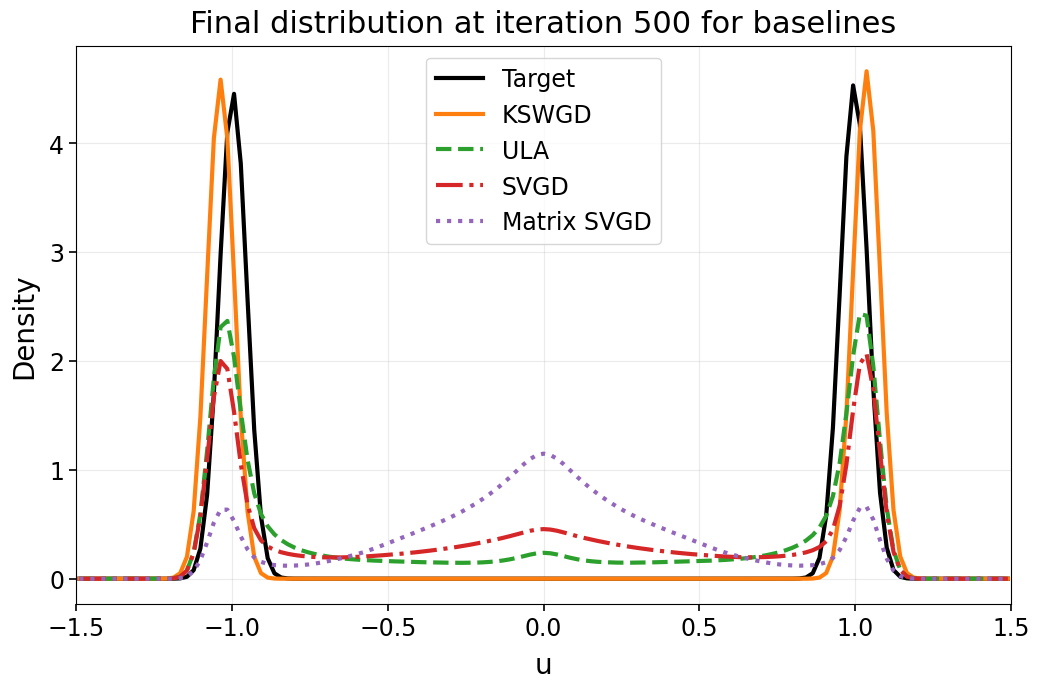

Saved: figures/allen_cahn/ac_comparison_particle_baselines.png
Saved: figures/allen_cahn/ac_comparison_particle_baselines.pdf


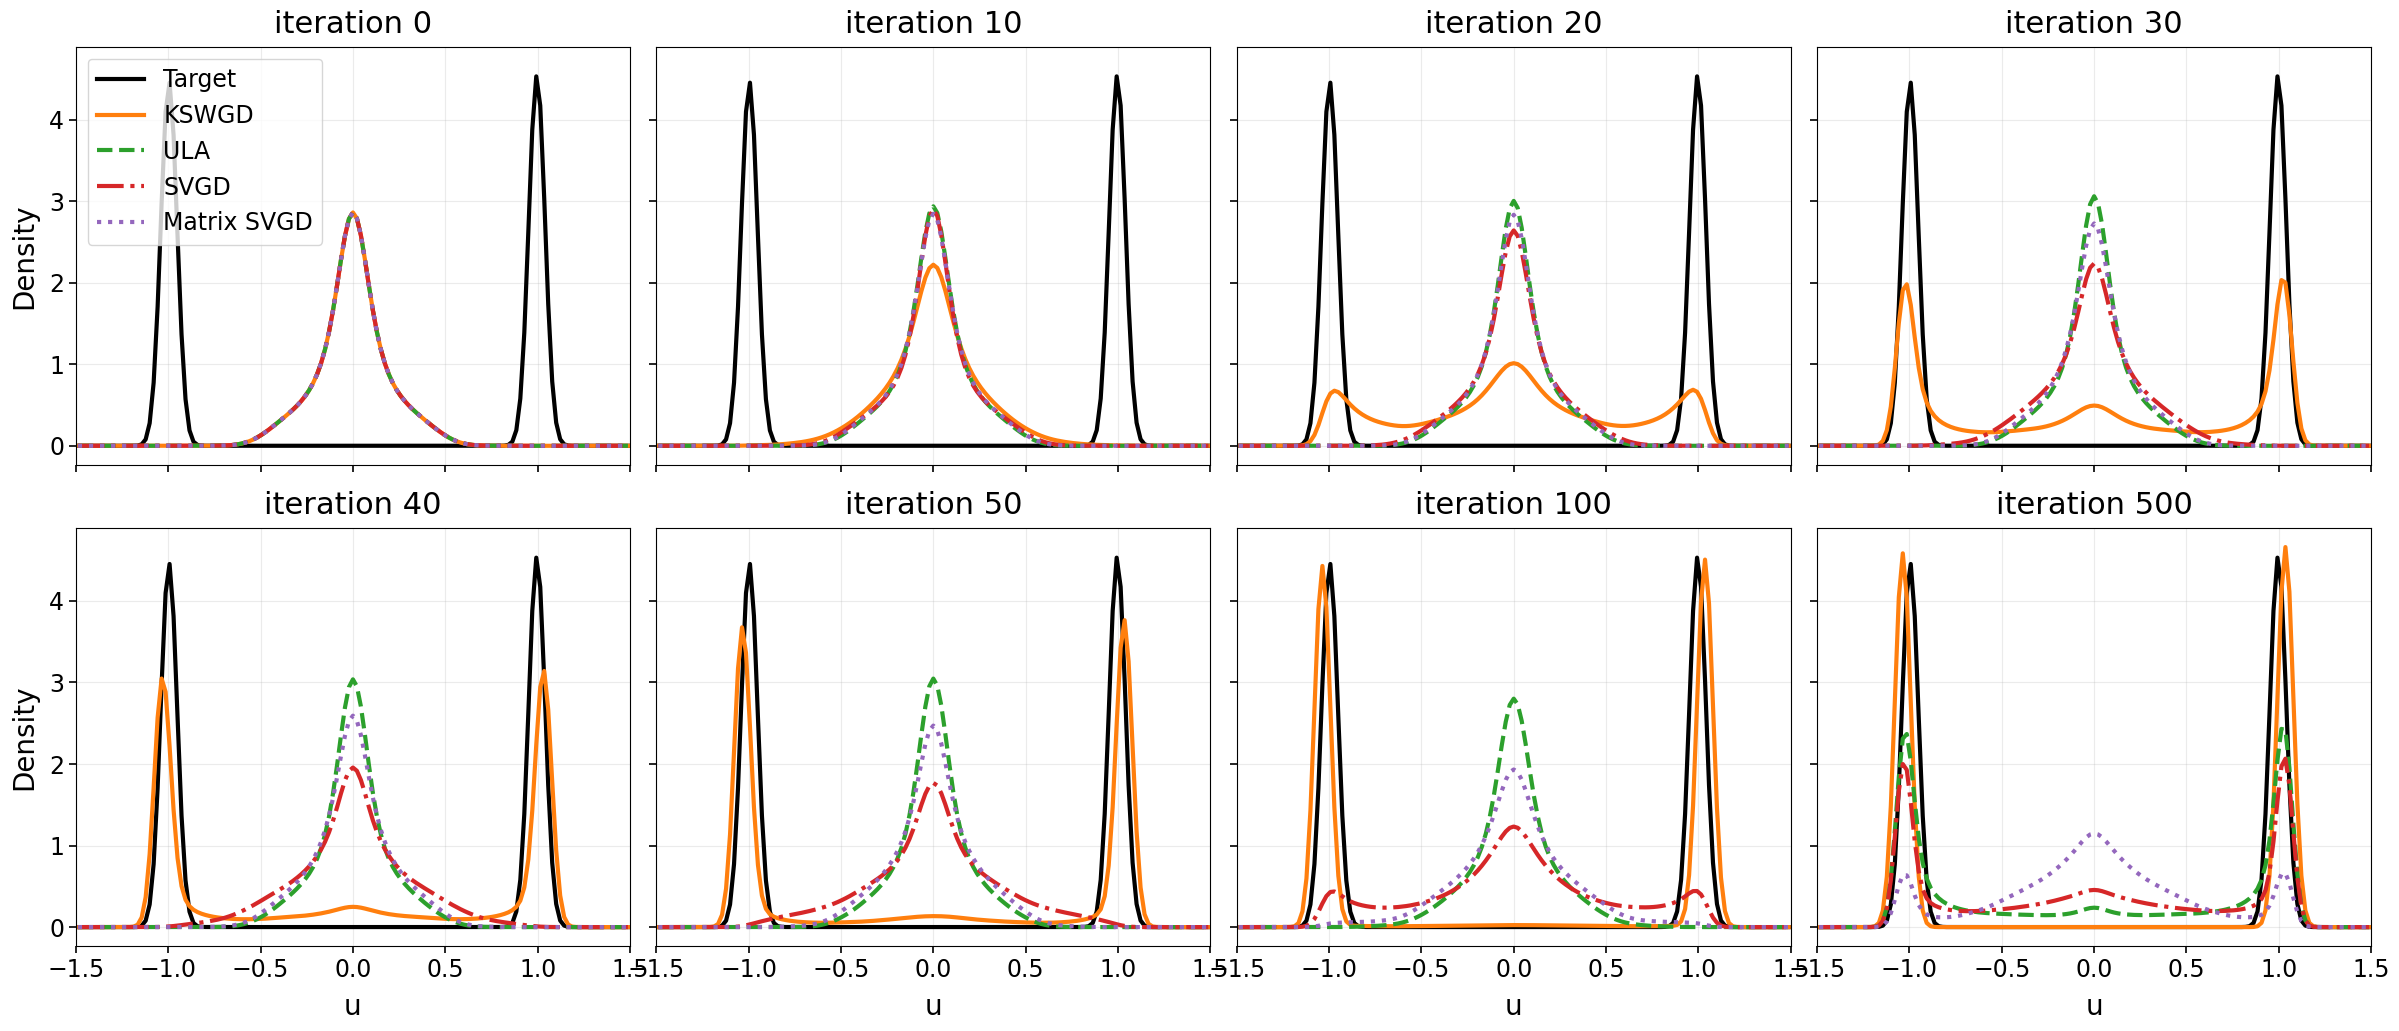

Saved: figures/allen_cahn/ac_comparison_particle_iteration_trends.png
Saved: figures/allen_cahn/ac_comparison_particle_iteration_trends.pdf


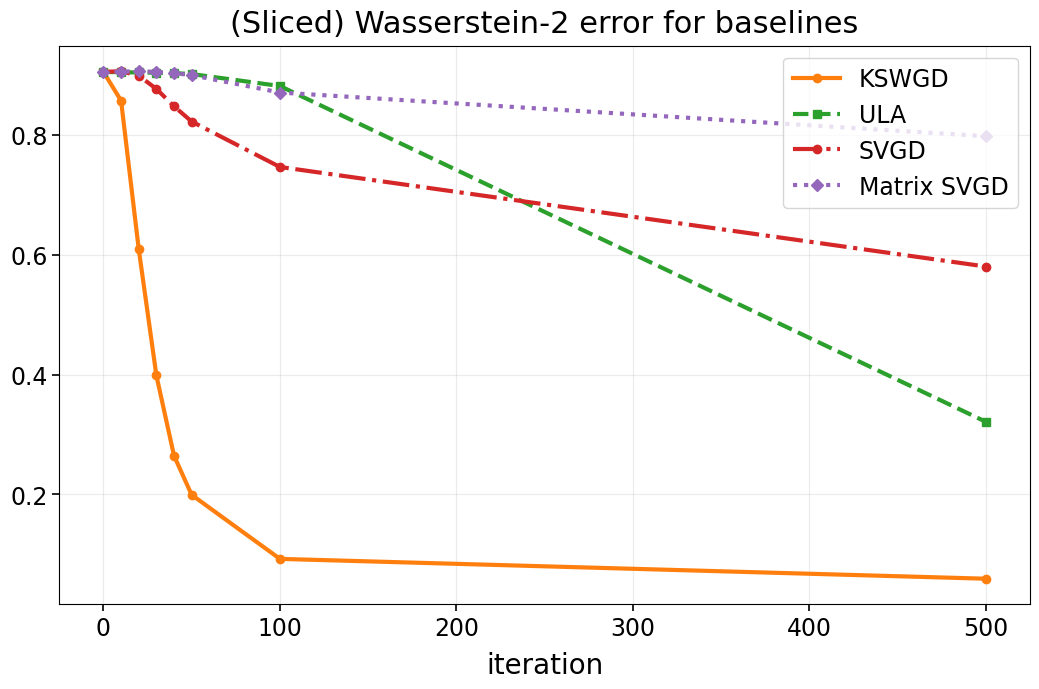

Saved: figures/allen_cahn/ac_comparison_particle_error_curves.png
Saved: figures/allen_cahn/ac_comparison_particle_error_curves.pdf
Error curve uses (Sliced) Wasserstein-2 on flattened decoded fields.
MMD uses decoded target fields and combined-median RBF bandwidth scale=2.


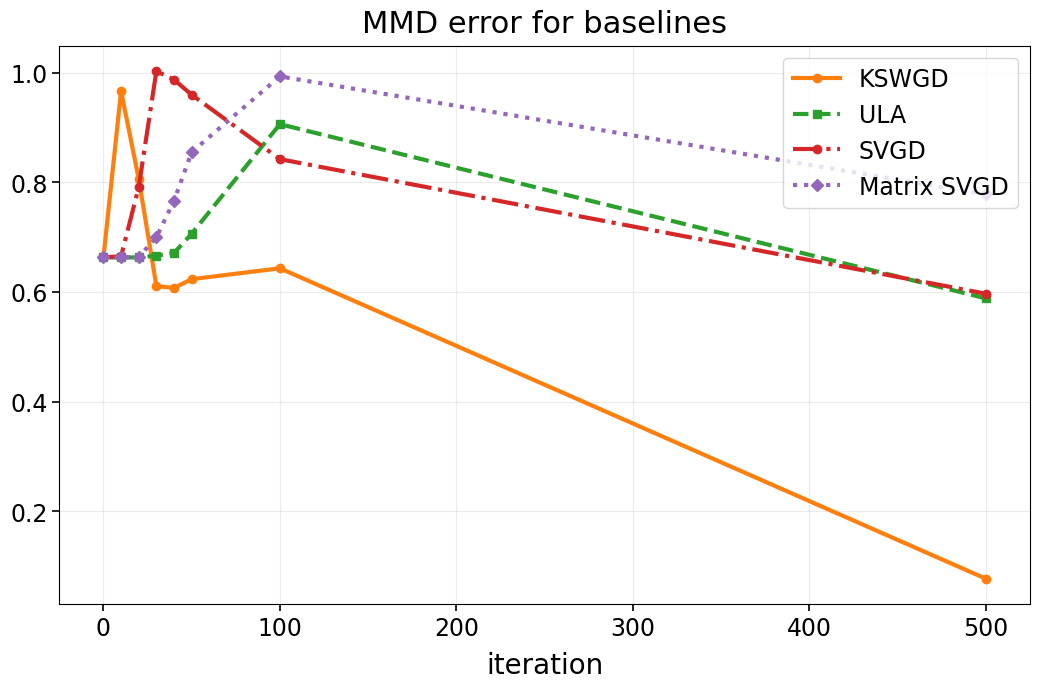

Saved: figures/allen_cahn/ac_comparison_particle_mmd_curves.png
Saved: figures/allen_cahn/ac_comparison_particle_mmd_curves.pdf
MMD curve uses decoded target fields and the same RBF-MMD as the summary table.

Field-level summary, sorted by (Sliced) Wasserstein-2 (lower is better)
Decoded-target sanity check (not ranked): raw-target SW2=0.05937, MMD=0.00416
Rank Method                 (Sliced) Wasserstein-2            MMD
   1 KSWGD                                 0.05937       0.076959
   2 ULA                                   0.32122       0.588291
   3 SVGD                                  0.58032       0.596744
   4 Matrix SVGD                           0.79785       0.778000
----------------------------------------------------------------------------
(Sliced) Wasserstein-2: computed on flattened decoded fields against raw PDE target fields.
MMD: RBF-MMD on flattened decoded fields against AE-reconstructed target fields decode(Z_tar).


In [141]:
# ============================================================
# Distribution comparison figures and summary statistics
# ============================================================

DISTRIBUTION_BINS = np.linspace(-1.5, 1.5, 140)
PRIMARY_ERROR_KEY = 'sw2_field'
PRIMARY_ERROR_LABEL = '(Sliced) Wasserstein-2'
SUMMARY_PARTICLE_METHODS = ['ULA', 'SVGD', 'Matrix SVGD']
FIELD_METRIC_MAX_SAMPLES = min(96, n_compare)
FIELD_SW_PROJECTIONS = 64


def finite_values(values):
    values = np.asarray(values).ravel()
    return values[np.isfinite(values)]


def quantile_w2_1d(a, b, n_grid=1000):
    a = np.sort(finite_values(a))
    b = np.sort(finite_values(b))
    if len(a) == 0 or len(b) == 0:
        return np.nan
    q = np.linspace(0.0, 1.0, n_grid)
    aq = np.interp(q, np.linspace(0.0, 1.0, len(a)), a)
    bq = np.interp(q, np.linspace(0.0, 1.0, len(b)), b)
    return float(np.sqrt(np.mean((aq - bq) ** 2)))


def fields_to_matrix(fields, max_samples=FIELD_METRIC_MAX_SAMPLES):
    arr = np.asarray(fields, dtype=np.float64)
    if arr.ndim < 2:
        return np.empty((0, 0), dtype=np.float64)
    arr = arr[:min(max_samples, arr.shape[0])]
    mat = arr.reshape(arr.shape[0], -1)
    mask = np.all(np.isfinite(mat), axis=1)
    return mat[mask]


target_field_matrix = fields_to_matrix(target_compare)
mmd_target_field_matrix = fields_to_matrix(ae_recon_compare)


def median_positive_sq_distance(matrix):
    if matrix.size == 0 or len(matrix) < 2:
        return 1.0
    D = pairwise_sq_np(matrix)
    vals = D[np.triu_indices_from(D, k=1)]
    vals = vals[vals > 0]
    return float(np.median(vals)) if len(vals) else 1.0


FIELD_MMD_BANDWIDTH_SCALE = 2.0


def sliced_w2_fields(samples, target_matrix=target_field_matrix, n_projections=FIELD_SW_PROJECTIONS, seed=RANDOM_SEED + 303):
    X = fields_to_matrix(samples)
    Y = target_matrix
    if X.size == 0 or Y.size == 0 or X.shape[1] != Y.shape[1]:
        return np.nan
    rng = np.random.default_rng(seed)
    directions = rng.normal(size=(n_projections, X.shape[1]))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    values = []
    for direction in directions:
        values.append(quantile_w2_1d(X @ direction, Y @ direction, n_grid=1000) ** 2)
    return float(np.sqrt(np.mean(values)))


def rbf_mmd_fields(samples, target_matrix=mmd_target_field_matrix, max_samples=FIELD_METRIC_MAX_SAMPLES):
    X = fields_to_matrix(samples, max_samples=max_samples)
    Y = target_matrix[:min(max_samples, len(target_matrix))]
    if X.size == 0 or Y.size == 0 or X.shape[1] != Y.shape[1]:
        return np.nan
    bw = FIELD_MMD_BANDWIDTH_SCALE * median_positive_sq_distance(np.vstack([X, Y]))
    bw = max(float(bw), 1e-12)
    Kxx = np.exp(-pairwise_sq_np(X) / (2.0 * bw))
    Kyy = np.exp(-pairwise_sq_np(Y) / (2.0 * bw))
    Kxy = np.exp(-pairwise_sq_np(X, Y) / (2.0 * bw))
    nx, ny = len(X), len(Y)
    term_x = (Kxx.sum() - np.trace(Kxx)) / (nx * (nx - 1)) if nx > 1 else Kxx.mean()
    term_y = (Kyy.sum() - np.trace(Kyy)) / (ny * (ny - 1)) if ny > 1 else Kyy.mean()
    mmd2 = term_x + term_y - 2.0 * Kxy.mean()
    return float(np.sqrt(max(mmd2, 0.0)))


if plt is None:
    print('matplotlib is not installed; skipping comparison plots.')
else:
    bins = DISTRIBUTION_BINS
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    smooth_sigma = 2
    font_title = 22
    font_label = 20
    font_tick = 17
    font_legend = 17
    line_width = 3.0

    def smooth_hist(values):
        values = finite_values(values)
        if len(values) == 0:
            return np.full(len(bin_centers), np.nan)
        hist, _ = np.histogram(values, bins=bins, density=True)
        return gaussian_filter1d(hist, sigma=smooth_sigma)

    target_hist = smooth_hist(target_compare)
    kswgd_hist = smooth_hist(kswgd_final_samples)

    def style_axis(ax):
        ax.set_xlabel('u', fontsize=font_label, labelpad=8)
        ax.set_ylabel('Density', fontsize=font_label, labelpad=8)
        ax.set_xlim(-1.5, 1.5)
        ax.tick_params(axis='both', labelsize=font_tick, width=1.2, length=5)
        ax.grid(alpha=0.25)

    particle_styles = {
        'ULA': {'color': '#2ca02c', 'linestyle': '--', 'marker': 's'},
        'SVGD': {'color': '#d62728', 'linestyle': '-.', 'marker': 'o'},
        'Matrix SVGD': {'color': '#9467bd', 'linestyle': ':', 'marker': 'D'},
    }
    particle_traj_methods = [
        name for name in SUMMARY_PARTICLE_METHODS
        if name in particle_baseline_results and 'samples_by_step' in particle_baseline_results[name]
    ]

    # ---------- Particle baselines: final samples ----------
    fig, ax = plt.subplots(figsize=(10.5, 7.0))
    ax.plot(bin_centers, target_hist, color='black', linewidth=line_width, label='Target')
    ax.plot(bin_centers, kswgd_hist, color='#ff7f0e', linewidth=line_width, label=KSWGD_LABEL)
    for name, style in particle_styles.items():
        ax.plot(
            bin_centers,
            smooth_hist(particle_baseline_results[name]['samples']),
            color=style['color'],
            linewidth=line_width,
            linestyle=style['linestyle'],
            label=name,
        )
    ax.set_title(f'Final distribution at iteration {PARTICLE_N_STEPS} for baselines', fontsize=font_title, pad=10)
    style_axis(ax)
    ax.legend(fontsize=font_legend, frameon=True)
    plt.tight_layout()
    fig_path_png = FIG_DIR / 'ac_comparison_particle_baselines.png'
    fig_path_pdf = FIG_DIR / 'ac_comparison_particle_baselines.pdf'
    plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
    plt.savefig(fig_path_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path_png}')
    print(f'Saved: {fig_path_pdf}')

    # ---------- Particle methods at matched iteration steps ----------
    if particle_traj_methods:
        n_rows, n_cols = 2, 4
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 10.5), sharex=True, sharey=True)
        axes_flat = axes.ravel()
        for ax_idx, ax in enumerate(axes_flat):
            if ax_idx >= len(snapshot_steps_kswgd):
                ax.axis('off')
                continue
            step = snapshot_steps_kswgd[ax_idx]
            ax.plot(bin_centers, target_hist, color='black', linewidth=line_width, label='Target')
            ax.plot(bin_centers, smooth_hist(decoded_by_step[step]), color='#ff7f0e', linewidth=line_width, label=KSWGD_LABEL)
            for name in particle_traj_methods:
                style = particle_styles[name]
                ax.plot(
                    bin_centers,
                    smooth_hist(particle_baseline_results[name]['samples_by_step'][step]),
                    color=style['color'],
                    linewidth=line_width,
                    linestyle=style['linestyle'],
                    label=name,
                )
            ax.set_title(f'iteration {step}', fontsize=font_title, pad=10)
            ax.set_xlim(-1.5, 1.5)
            ax.grid(alpha=0.25)
            ax.tick_params(axis='both', labelsize=font_tick, width=1.2, length=5)
            if ax_idx // n_cols == n_rows - 1:
                ax.set_xlabel('u', fontsize=font_label, labelpad=8)
            if ax_idx % n_cols == 0:
                ax.set_ylabel('Density', fontsize=font_label, labelpad=8)
        axes_flat[0].legend(loc='upper left', fontsize=font_legend, frameon=True)
        plt.tight_layout(pad=1.4)
        fig_path_png = FIG_DIR / 'ac_comparison_particle_iteration_trends.png'
        fig_path_pdf = FIG_DIR / 'ac_comparison_particle_iteration_trends.pdf'
        plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
        plt.savefig(fig_path_pdf, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path_png}')
        print(f'Saved: {fig_path_pdf}')

    # ---------- Particle sliced Wasserstein error curve ----------
    fig, ax = plt.subplots(figsize=(10.5, 7.0))
    kswgd_errors = [sliced_w2_fields(decoded_by_step[step]) for step in snapshot_steps_kswgd]
    ax.plot(snapshot_steps_kswgd, kswgd_errors, marker='o', linewidth=line_width, color='#ff7f0e', label=KSWGD_LABEL)
    for name in particle_traj_methods:
        style = particle_styles[name]
        steps = sorted(particle_baseline_results[name]['samples_by_step'].keys())
        errors = [sliced_w2_fields(particle_baseline_results[name]['samples_by_step'][step]) for step in steps]
        ax.plot(steps, errors, marker=style['marker'], linewidth=line_width, linestyle=style['linestyle'], color=style['color'], label=name)
    ax.set_title('(Sliced) Wasserstein-2 error for baselines', fontsize=font_title, pad=10)
    ax.set_xlabel('iteration', fontsize=font_label, labelpad=8)
    ax.set_ylabel('', fontsize=font_label, labelpad=8)
    ax.tick_params(axis='both', labelsize=font_tick, width=1.2, length=5)
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=font_legend, frameon=True)
    plt.tight_layout()
    fig_path_png = FIG_DIR / 'ac_comparison_particle_error_curves.png'
    fig_path_pdf = FIG_DIR / 'ac_comparison_particle_error_curves.pdf'
    plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
    plt.savefig(fig_path_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path_png}')
    print(f'Saved: {fig_path_pdf}')
    print('Error curve uses (Sliced) Wasserstein-2 on flattened decoded fields.')
    print(f'MMD uses decoded target fields and combined-median RBF bandwidth scale={FIELD_MMD_BANDWIDTH_SCALE:g}.')

    # ---------- Particle MMD error curve ----------
    fig, ax = plt.subplots(figsize=(10.5, 7.0))
    kswgd_mmd_errors = [rbf_mmd_fields(decoded_by_step[step]) for step in snapshot_steps_kswgd]
    ax.plot(snapshot_steps_kswgd, kswgd_mmd_errors, marker='o', linewidth=line_width, color='#ff7f0e', label=KSWGD_LABEL)
    for name in particle_traj_methods:
        style = particle_styles[name]
        steps = sorted(particle_baseline_results[name]['samples_by_step'].keys())
        errors = [rbf_mmd_fields(particle_baseline_results[name]['samples_by_step'][step]) for step in steps]
        ax.plot(steps, errors, marker=style['marker'], linewidth=line_width, linestyle=style['linestyle'], color=style['color'], label=name)
    ax.set_title('MMD error for baselines', fontsize=font_title, pad=10)
    ax.set_xlabel('iteration', fontsize=font_label, labelpad=8)
    ax.set_ylabel('', fontsize=font_label, labelpad=8)
    ax.tick_params(axis='both', labelsize=font_tick, width=1.2, length=5)
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=font_legend, frameon=True)
    plt.tight_layout()
    fig_path_png = FIG_DIR / 'ac_comparison_particle_mmd_curves.png'
    fig_path_pdf = FIG_DIR / 'ac_comparison_particle_mmd_curves.pdf'
    plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
    plt.savefig(fig_path_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path_png}')
    print(f'Saved: {fig_path_pdf}')
    print('MMD curve uses decoded target fields and the same RBF-MMD as the summary table.')


summary_rows = []
def add_summary(name, samples):
    summary_rows.append({
        'method': name,
        'sw2_field': sliced_w2_fields(samples),
        'mmd_field': rbf_mmd_fields(samples),
    })

add_summary(KSWGD_LABEL, kswgd_final_samples)
for name in SUMMARY_PARTICLE_METHODS:
    if name in particle_baseline_results:
        add_summary(name, particle_baseline_results[name]['samples'])

summary_rows_sorted = sorted(
    summary_rows,
    key=lambda row: row[PRIMARY_ERROR_KEY] if np.isfinite(row[PRIMARY_ERROR_KEY]) else np.inf,
)
ae_recon_summary = {
    'sw2_field': sliced_w2_fields(ae_recon_compare),
    'mmd_field': rbf_mmd_fields(ae_recon_compare),
}

print()
print('=' * 76)
print(f'Field-level summary, sorted by {PRIMARY_ERROR_LABEL} (lower is better)')
print('=' * 76)
print(f"Decoded-target sanity check (not ranked): raw-target SW2={ae_recon_summary['sw2_field']:.5f}, MMD={ae_recon_summary['mmd_field']:.5f}")
print(f"{'Rank':>4s} {'Method':18s} {'(Sliced) Wasserstein-2':>26s} {'MMD':>14s}")
for rank, row in enumerate(summary_rows_sorted, start=1):
    print(f"{rank:4d} {row['method']:18s} {row['sw2_field']:26.5f} {row['mmd_field']:14.6f}")
print('-' * 76)
print('(Sliced) Wasserstein-2: computed on flattened decoded fields against raw PDE target fields.')
print('MMD: RBF-MMD on flattened decoded fields against AE-reconstructed target fields decode(Z_tar).')
print('=' * 76)
